# Extraction temporelle — tweets (SynTime)

Évaluation du modèle BERT sur des tweets annotés TIMEX3 du jeu de test SynTime, en correspondance stricte puis souple. Le fichier `tweets.csv` est produit par `tweets_preprocess.ipynb`.

### Imports

In [ ]:
import os
import sqlite3
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from transformers import pipeline
import logging
import re

logging.getLogger("transformers").setLevel(logging.ERROR)

### Configuration gpu

In [ ]:
device = 0 if torch.cuda.is_available() else -1
print(f"🚀 Accélérateur : {'GPU ' + torch.cuda.get_device_name(0) if device == 0 else 'CPU'}")

### Détection de type à partir de val (iso 8601)

In [ ]:
def determine_type_from_val(val):
    if not val:
        return 'UNKNOWN'
    val = str(val).upper().strip()
    if val.startswith('P'):
        return 'DURATION'
    if 'T' in val:
        t_index = val.index('T')
        after_t = val[t_index+1:] if t_index+1 < len(val) else ''
        if after_t:
            if after_t[0].isdigit():
                return 'TIME'
            if len(after_t) >= 2 and after_t[:2] in ['MO', 'AF', 'EV', 'NI']:
                return 'TIME'
    if 'XXXX' in val or 'WXX' in val:
        return 'SET'
    if '-' in val or (val.isdigit() and len(val) == 4):
        return 'DATE'
    return 'UNKNOWN'

### Extraction des entités depuis le texte annoté

In [ ]:
def extract_gold_entities_from_annotated_text(texte_annote):
    entities = []
    try:
        wrapped_text = f"<root>{texte_annote}</root>"
        soup = BeautifulSoup(wrapped_text, 'xml')
        timex_tags = soup.find_all(['TIMEX3', 'timex3'])
        for timex in timex_tags:
            tid = timex.get('tid', '')
            val = timex.get('value', '')
            t_type = timex.get('type', '')
            if not t_type:
                t_type = determine_type_from_val(val)
            entity_text = timex.get_text().strip()
            context = texte_annote
            entities.append({
                'text': entity_text,
                'value': val,
                'type': t_type,
                'tid': tid,
                'context': context,
                'source': 'GOLD'
            })
    except Exception as e:
        print(f"⚠️ Erreur lors de l'extraction: {e}")
    return entities

### Chargement du dataset tweets

In [ ]:
def load_tweets_dataset(csv_path):
    print(f"\n📂 Chargement du dataset : {csv_path}")
    try:
        df_tweets = pd.read_csv(csv_path, encoding='utf-8')
        required_cols = ['texte', 'texte_annote', 'fichier']
        if not all(col in df_tweets.columns for col in required_cols):
            print(f"⚠️ Colonnes manquantes. Colonnes trouvées: {df_tweets.columns.tolist()}")
            return None
        print(f"✅ {len(df_tweets)} tweets chargés")
        return df_tweets
    except Exception as e:
        print(f"❌ Erreur lors du chargement: {e}")
        return None

### Extraction des entités gold

In [ ]:
def extract_all_gold_entities(df_tweets):
    print("\n🔍 Extraction des entités gold depuis les annotations...")
    all_entities = []
    for idx, row in df_tweets.iterrows():
        entities = extract_gold_entities_from_annotated_text(row['texte_annote'])
        for entity in entities:
            entity['fichier'] = row['fichier']
            all_entities.append(entity)
    if not all_entities:
        return pd.DataFrame(columns=['text', 'value', 'type', 'tid', 'context', 'source', 'fichier'])
    df_gold = pd.DataFrame(all_entities)
    print(f"✅ {len(df_gold)} entités gold extraites")
    print(f"\n📊 Distribution des types:\n{df_gold['type'].value_counts()}")
    return df_gold

### Extraction via bert

In [ ]:
def extract_temporal_entities_bert(texts_list):
    print("\n🤖 Démarrage du modèle Transformer...")
    model_name = "satyaalmasian/temporal_tagger_BERT_tokenclassifier"
    try:
        nlp = pipeline("token-classification", model=model_name, aggregation_strategy="simple", device=device, batch_size=32)
    except:
        nlp = pipeline("ner", model="dslim/bert-base-NER", aggregation_strategy="simple", device=device, batch_size=32)
    print(f"⚡ Analyse de {len(texts_list)} tweets...")
    extracted_entities = []
    try:
        results_list = nlp(texts_list)
        for text_id, (text, results) in enumerate(zip(texts_list, results_list)):
            for ent in results:
                entity_text = ent['word']
                start_pos = text.find(entity_text)
                context = text[:start_pos] + f"[{entity_text}]" + text[start_pos+len(entity_text):] if start_pos != -1 else text
                extracted_entities.append({
                    'text': entity_text,
                    'type': ent.get('entity_group', 'UNKNOWN'),
                    'context': context,
                    'score': round(ent['score'], 3),
                    'text_id': text_id
                })
    except Exception as e:
        print(f"❌ Erreur: {e}")
        return pd.DataFrame(columns=['text', 'type', 'context', 'score', 'text_id'])
    if not extracted_entities:
        return pd.DataFrame(columns=['text', 'type', 'context', 'score', 'text_id'])
    df = pd.DataFrame(extracted_entities)
    print(f"✅ {len(df)} entités extraites\n📊 Distribution:\n{df['type'].value_counts()}")
    return df

### Fonctions d'évaluation (identiques au code original)

In [ ]:
def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

def texts_match(text1, text2, exact_match=True):
    norm1 = normalize_text(text1)
    norm2 = normalize_text(text2)
    if norm1 == norm2:
        return True
    if not exact_match and (norm1 in norm2 or norm2 in norm1):
        return True
    return False

def evaluate_detection(df_gold, df_pred):
    print("\n📊 ÉVALUATION 1 : DÉTECTION D'ENTITÉS")
    print("=" * 60)
    if df_gold.empty or df_pred.empty:
        return 0, 0, 0
    golds = df_gold['text'].tolist()
    preds = df_pred['text'].tolist()
    tp = fp = fn = 0
    matched_preds = set()
    for g in golds:
        match_found = False
        for i, p in enumerate(preds):
            if i not in matched_preds and texts_match(g, p):
                match_found = True
                matched_preds.add(i)
                break
        tp += match_found
        fn += not match_found
    fp = len(preds) - len(matched_preds)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    print(f"🎯 TP: {tp} | ❌ FP: {fp} | 📉 FN: {fn}")
    print(f"🏆 PRÉCISION: {precision:.2%} | RAPPEL: {recall:.2%} | F1: {f1:.2%}")
    return precision, recall, f1

def evaluate_classification(df_gold, df_pred):
    print("\n📊 ÉVALUATION 2 : CLASSIFICATION DES TYPES")
    print("=" * 60)
    if df_gold.empty or df_pred.empty:
        return 0, 0, 0
    golds = [(row['text'], row['type']) for _, row in df_gold.iterrows()]
    preds = [(row['text'], row['type']) for _, row in df_pred.iterrows()]
    tp_type = fp_type = fn_type = 0
    matched_preds = set()
    for g_text, g_type in golds:
        match_found = False
        for i, (p_text, p_type) in enumerate(preds):
            if i not in matched_preds and texts_match(g_text, p_text):
                match_found = True
                matched_preds.add(i)
                tp_type += (g_type == p_type)
                fp_type += (g_type != p_type)
                break
        fn_type += not match_found
    precision = tp_type / (tp_type + fp_type) if (tp_type + fp_type) > 0 else 0
    recall = tp_type / (tp_type + fn_type) if (tp_type + fn_type) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    print(f"🎯 Corrects: {tp_type} | ❌ Incorrects: {fp_type} | 📉 Non détectés: {fn_type}")
    print(f"🏆 PRÉCISION: {precision:.2%} | RAPPEL: {recall:.2%} | F1: {f1:.2%}")
    return precision, recall, f1

### Visualisation (version condensée)

In [ ]:
def plot_comprehensive_statistics(df_gold, df_pred, dataset_name, det_scores, clf_scores):
    fig = plt.figure(figsize=(18, 10))
    # Graph 1: Types distribution
    ax1 = plt.subplot(2, 3, 1)
    data_dict = {}
    if not df_gold.empty:
        data_dict['Gold'] = df_gold['type'].value_counts()
    if not df_pred.empty:
        data_dict['Prédit'] = df_pred['type'].value_counts()
    df_plot = pd.DataFrame(data_dict).fillna(0)
    if not df_plot.empty:
        df_plot.plot(kind='bar', ax=ax1, color=['#2ecc71', '#3498db'])
        ax1.set_title("Distribution des Types", fontweight='bold')
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    # Graphs 2-3: Detection and Classification scores
    for idx, (scores, title, ax_pos) in enumerate([(det_scores, "Détection", 2), (clf_scores, "Classification", 3)]):
        ax = plt.subplot(2, 3, ax_pos)
        bars = ax.bar(['Précision', 'Rappel', 'F1'], scores, color=['#e74c3c', '#f39c12', '#9b59b6'], alpha=0.7)
        ax.set_title(f"Scores {title}", fontweight='bold')
        ax.set_ylim(0, 1)
        for bar, val in zip(bars, scores):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{val:.1%}', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    output = f'stats_{dataset_name}.png'
    plt.savefig(output, dpi=150, bbox_inches='tight')
    print(f"✅ Graphiques: {output}")
    plt.show()

### Base de données (version condensée)

In [ ]:
def match_predictions_to_gold(df_pred, df_gold):
    results = []
    matched_gold = set()
    for _, pred_row in df_pred.iterrows():
        match_found = False
        for gold_idx, gold_row in df_gold.iterrows():
            if gold_idx not in matched_gold and texts_match(pred_row['text'], gold_row['text']):
                matched_gold.add(gold_idx)
                results.append({
                    'predicted_text': pred_row['text'], 'predicted_type': pred_row['type'],
                    'gold_text': gold_row['text'], 'gold_type': gold_row['type'], 'gold_value': gold_row.get('value'),
                    'entity_matched': True, 'type_matched': pred_row['type']==gold_row['type'], 'status': 'TRUE_POSITIVE'
                })
                match_found = True
                break
        if not match_found:
            results.append({
                'predicted_text': pred_row['text'], 'predicted_type': pred_row['type'],
                'gold_text': "N/A", 'gold_type': "N/A", 'gold_value': "N/A",
                'entity_matched': False, 'type_matched': False, 'status': 'FALSE_POSITIVE'
            })
    for gold_idx, gold_row in df_gold.iterrows():
        if gold_idx not in matched_gold:
            results.append({
                'predicted_text': "N/A", 'predicted_type': "N/A",
                'gold_text': gold_row['text'], 'gold_type': gold_row['type'], 'gold_value': gold_row.get('value'),
                'entity_matched': False, 'type_matched': False, 'status': 'FALSE_NEGATIVE'
            })
    return pd.DataFrame(results)

def export_to_unified_db(df_pred, df_gold, table_name, db_name="tweets_temporel.db"):
    df_enriched = match_predictions_to_gold(df_pred, df_gold)
    if df_enriched.empty:
        return
    conn = sqlite3.connect(db_name)
    c = conn.cursor()
    c.execute(f'''CREATE TABLE IF NOT EXISTS `{table_name}` (
        id INTEGER PRIMARY KEY, predicted_text TEXT, predicted_type TEXT,
        gold_text TEXT, gold_type TEXT, gold_value TEXT,
        entity_matched BOOLEAN, type_matched BOOLEAN, status TEXT)''')
    for _, row in df_enriched.iterrows():
        c.execute(f'INSERT INTO `{table_name}` VALUES (NULL,?,?,?,?,?,?,?,?)',
                 (row['predicted_text'], row['predicted_type'], row['gold_text'],
                  row['gold_type'], row['gold_value'], row['entity_matched'],
                  row['type_matched'], row['status']))
    conn.commit()
    print(f"✅ {len(df_enriched)} lignes dans '{table_name}'")
    conn.close()

### Pipeline principal

In [ ]:
def run_tweets_pipeline(csv_path, db_name="tweets_temporel_exacte.db"):
    print("\n" + "=" * 80)
    print("🚀 PIPELINE D'EXTRACTION TEMPORELLE - TWEETS")
    print("=" * 80)
    
    df_tweets = load_tweets_dataset(csv_path)
    if df_tweets is None:
        return None
    
    df_gold = extract_all_gold_entities(df_tweets)
    df_pred = extract_temporal_entities_bert(df_tweets['texte'].tolist())
    
    det_scores = evaluate_detection(df_gold, df_pred)
    clf_scores = evaluate_classification(df_gold, df_pred)
    
    plot_comprehensive_statistics(df_gold, df_pred, "tweets", det_scores, clf_scores)
    export_to_unified_db(df_pred, df_gold, "tweets_results", db_name)
    
    print("\n" + "=" * 80)
    print("✅ PIPELINE TERMINÉ")
    print("=" * 80)
    
    return {
        'detection': {'precision': det_scores[0], 'recall': det_scores[1], 'f1': det_scores[2]},
        'classification': {'precision': clf_scores[0], 'recall': clf_scores[1], 'f1': clf_scores[2]},
        'df_gold': df_gold,
        'df_pred': df_pred
    }

### Exécution — correspondance stricte

🚀 Accélérateur : GPU Tesla P100-PCIE-16GB

🚀 PIPELINE D'EXTRACTION TEMPORELLE - TWEETS

📂 Chargement du dataset : /kaggle/input/tweets-temporal/tweets.csv
✅ 200 tweets chargés

🔍 Extraction des entités gold depuis les annotations...
✅ 237 entités gold extraites

📊 Distribution des types:
type
DATE        164
TIME         34
DURATION     33
SET           6
Name: count, dtype: int64

🤖 Démarrage du modèle Transformer...
⚡ Analyse de 200 tweets...
✅ 247 entités extraites
📊 Distribution:
type
DATE        166
TIME         42
DURATION     34
SET           5
Name: count, dtype: int64

📊 ÉVALUATION 1 : DÉTECTION D'ENTITÉS
🎯 TP: 209 | ❌ FP: 38 | 📉 FN: 28
🏆 PRÉCISION: 84.62% | RAPPEL: 88.19% | F1: 86.36%

📊 ÉVALUATION 2 : CLASSIFICATION DES TYPES
🎯 Corrects: 201 | ❌ Incorrects: 8 | 📉 Non détectés: 28
🏆 PRÉCISION: 96.17% | RAPPEL: 87.77% | F1: 91.78%
✅ Graphiques: stats_tweets.png


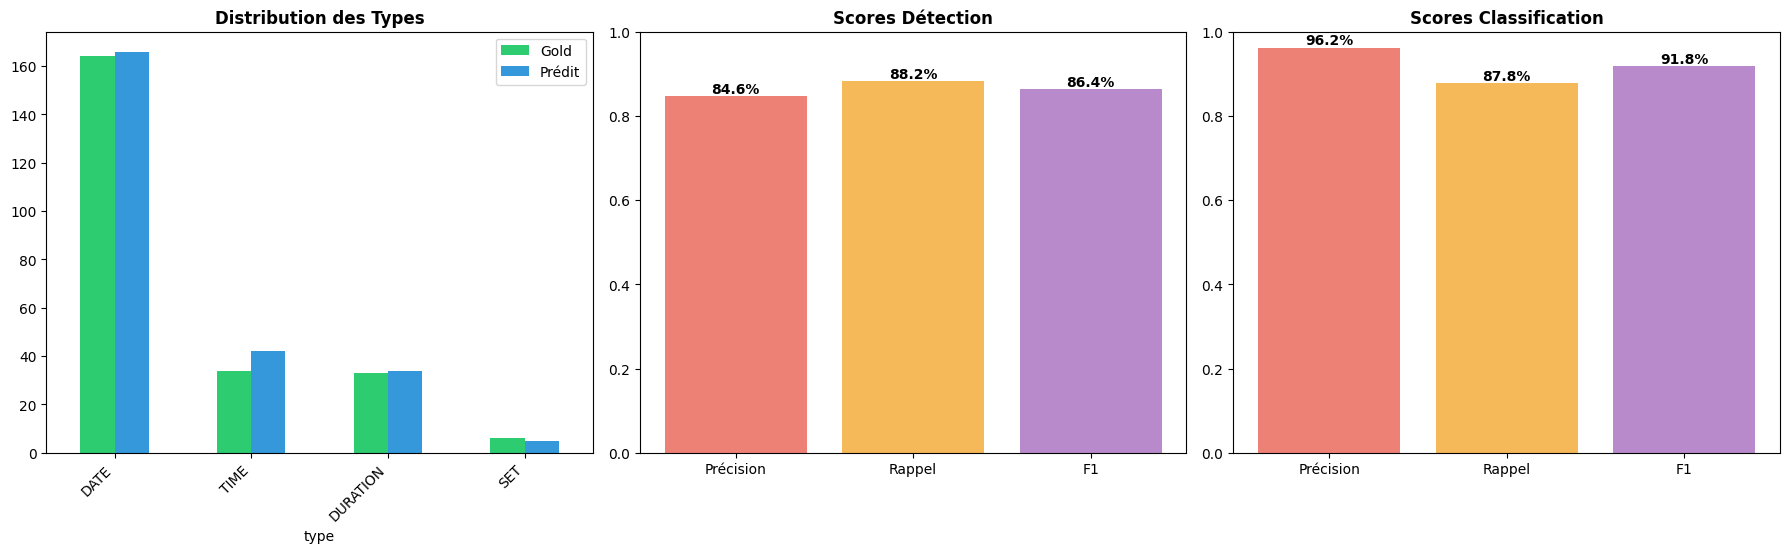

✅ 275 lignes dans 'tweets_results'

✅ PIPELINE TERMINÉ

📈 RÉSULTATS FINAUX:
Détection    - P: 84.62% R: 88.19% F1: 86.36%
Classification - P: 96.17% R: 87.77% F1: 91.78%


In [ ]:
# MODIFIER LE CHEMIN VERS VOTRE FICHIER CSV
csv_path = "/kaggle/input/tweets-temporal/tweets.csv"

results = run_tweets_pipeline(csv_path)

if results:
    print("\n📈 RÉSULTATS FINAUX:")
    print(f"Détection    - P: {results['detection']['precision']:.2%} R: {results['detection']['recall']:.2%} F1: {results['detection']['f1']:.2%}")
    print(f"Classification - P: {results['classification']['precision']:.2%} R: {results['classification']['recall']:.2%} F1: {results['classification']['f1']:.2%}")

### Exécution — correspondance souple

Seule la fonction `texts_match` change : les correspondances partielles sont acceptées.

🚀 Accélérateur : GPU Tesla P100-PCIE-16GB

🚀 PIPELINE D'EXTRACTION TEMPORELLE - TWEETS

📂 Chargement du dataset : /kaggle/input/tweets-temporal/tweets.csv
✅ 200 tweets chargés

🔍 Extraction des entités gold depuis les annotations...
✅ 237 entités gold extraites

📊 Distribution des types:
type
DATE        164
TIME         34
DURATION     33
SET           6
Name: count, dtype: int64

🤖 Démarrage du modèle Transformer...
⚡ Analyse de 200 tweets...
✅ 247 entités extraites
📊 Distribution:
type
DATE        166
TIME         42
DURATION     34
SET           5
Name: count, dtype: int64

📊 ÉVALUATION 1 : DÉTECTION D'ENTITÉS
🎯 TP: 231 | ❌ FP: 16 | 📉 FN: 6
🏆 PRÉCISION: 93.52% | RAPPEL: 97.47% | F1: 95.45%

📊 ÉVALUATION 2 : CLASSIFICATION DES TYPES
🎯 Corrects: 203 | ❌ Incorrects: 28 | 📉 Non détectés: 6
🏆 PRÉCISION: 87.88% | RAPPEL: 97.13% | F1: 92.27%
✅ Graphiques: stats_tweets.png


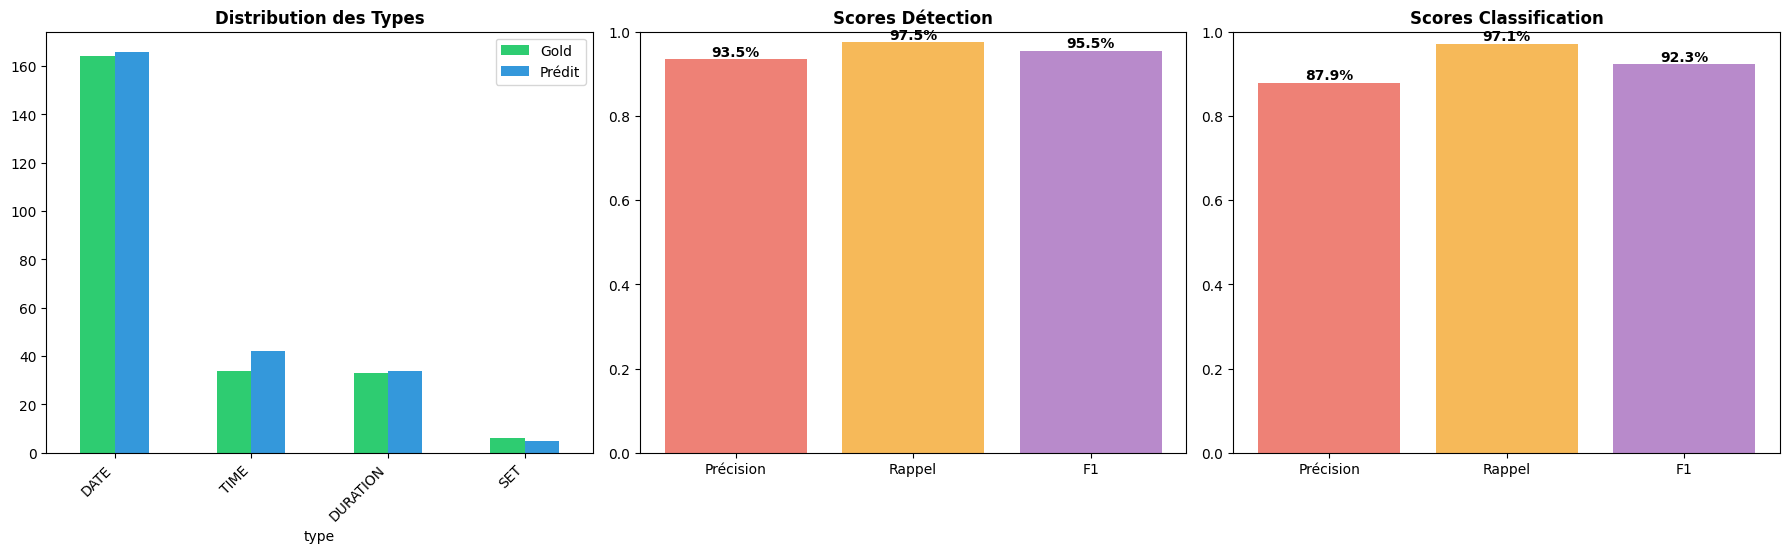

✅ 253 lignes dans 'tweets_results'

✅ PIPELINE TERMINÉ

📈 RÉSULTATS FINAUX:
Détection    - P: 93.52% R: 97.47% F1: 95.45%
Classification - P: 87.88% R: 97.13% F1: 92.27%


In [ ]:
def texts_match(text1, text2, exact_match=False):
    norm1 = normalize_text(text1)
    norm2 = normalize_text(text2)
    if norm1 == norm2:
        return True
    if not exact_match and (norm1 in norm2 or norm2 in norm1):
        return True
    return False


# Même pipeline, avec des correspondances partielles acceptées
csv_path = "/kaggle/input/tweets-temporal/tweets.csv"
results = run_tweets_pipeline(csv_path, db_name="tweets_temporel_souple.db")

if results:
    print("\n📈 RÉSULTATS FINAUX:")
    print(f"Détection    - P: {results['detection']['precision']:.2%} R: {results['detection']['recall']:.2%} F1: {results['detection']['f1']:.2%}")
    print(f"Classification - P: {results['classification']['precision']:.2%} R: {results['classification']['recall']:.2%} F1: {results['classification']['f1']:.2%}")